# Matemática para Ciencia de los Datos
# Trabajo Práctico 4

Profesor: Juan Luis Crespo Mariño (basado en trabajo previo del Prof. Dr. Luis Alexánder Calvo Valverde)

Instituto Tecnológico de Costa Rica,

Programa Ciencia de Datos

---

Fecha de entrega: 13 de marzo, hora límite las 6:00 pm.

Medio de entrega: Por medio del TEC-Digital.

Entregables: Un archivo jupyter ( .IPYNB ).

Estudiante(s):
1. **Carlos Esquivel**
1. **Antony Medina**



---

## Parte 1

Dada la siguiente matriz:

\begin{equation}
A= \begin{bmatrix}
   1.,2. \\
   3.,4.
\end{bmatrix}
\end{equation}




**Ejercicio 1.1 (25 puntos)**

En una celda de texto, calcule los auto-valores y deje planteada la ecuación para el cálculo de los los auto-vectores como los ejemplos vistos en clase. Debe mostrar todo el procedimiento.

**Cálculo Analítico de Auto-valores y Planteamiento de Auto-vectores**

Dada la matriz $A$:
$$A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}$$

**1. Cálculo de Auto-valores ($\lambda$)**
Para encontrar los auto-valores, debemos resolver la ecuación característica, donde el determinante de $(A - \lambda I)$ es igual a cero:
$$\det(A - \lambda I) = 0$$

Construimos la matriz $(A - \lambda I)$:
$$A - \lambda I = \begin{bmatrix} 1-\lambda & 2 \\ 3 & 4-\lambda \end{bmatrix}$$

Calculamos el determinante multiplicando la diagonal principal y restando el producto de la diagonal secundaria:
$$(1-\lambda)(4-\lambda) - (2)(3) = 0$$
$$4 - \lambda - 4\lambda + \lambda^2 - 6 = 0$$
$$\lambda^2 - 5\lambda - 2 = 0$$

Para resolver esta ecuación cuadrática ($a=1, b=-5, c=-2$), utilizamos la fórmula general:
$$\lambda = \frac{-(-5) \pm \sqrt{(-5)^2 - 4(1)(-2)}}{2(1)}$$
$$\lambda = \frac{5 \pm \sqrt{25 + 8}}{2}$$
$$\lambda = \frac{5 \pm \sqrt{33}}{2}$$

Por lo tanto, los dos auto-valores exactos son:
$$\lambda_1 = \frac{5 + \sqrt{33}}{2} \approx 5.37228$$
$$\lambda_2 = \frac{5 - \sqrt{33}}{2} \approx -0.37228$$

---

**2. Planteamiento de la ecuación para los Auto-vectores ($\vec{x}$)**
Por definición, un auto-vector $\vec{x} = \begin{bmatrix} x \\ y \end{bmatrix}$ asociado a un auto-valor $\lambda$ debe satisfacer la ecuación fundamental:
$$(A - \lambda I)\vec{x} = 0$$

Sustituyendo nuestra matriz, el sistema de ecuaciones queda planteado de la siguiente manera:
$$\begin{bmatrix} 1-\lambda & 2 \\ 3 & 4-\lambda \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$$

Esto se traduce en el siguiente sistema de ecuaciones lineales, el cual debe resolverse evaluando $\lambda_1$ y $\lambda_2$ individualmente:
1) $(1-\lambda)x + 2y = 0$
2) $3x + (4-\lambda)y = 0$


**Ejercicio 1.2 (25 puntos)**

En una celda de código y utilizando la función eig de numpy, calcule los auto-valores y auto-vectores y haga las operaciones en el código para mostrar que se cumple: $A\,\vec{x} = \lambda\vec{x}$ (No olvide las pequeñas posibles diferencias por precisión de la representación numérica).


In [ ]:
import numpy as np

# 1. Definir la matriz A
A = np.array([[1., 2.], 
              [3., 4.]])

# 2. Calcular auto-valores (eigenvalues) y auto-vectores (eigenvectors)
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Resultados de np.linalg.eig:")
print(f"Auto-valores: {eigenvalues}")
print(f"Auto-vectores:\n{eigenvectors}\n")

print("-" * 50)
print("Demostración de la propiedad: A*x = lambda*x")
print("-" * 50)


for i in range(len(eigenvalues)):
    
    lambd = eigenvalues[i]
    x = eigenvectors[:, i]
    
    
    left_side = np.dot(A, x)
    
    
    right_side = lambd * x
    
    print(f"\nEvaluando Componente {i+1} (lambda = {lambd:.5f}):")
    print(f"Lado Izquierdo (A*x):     {left_side}")
    print(f"Lado Derecho (lambda*x):  {right_side}")
    
    
    is_equal = np.allclose(left_side, right_side)
    print(f"¿Se cumple la igualdad A*x = lambda*x? -> {is_equal}")

Resultados de np.linalg.eig:
Auto-valores: [-0.37228132  5.37228132]
Auto-vectores:
[[-0.82456484 -0.41597356]
 [ 0.56576746 -0.90937671]]

--------------------------------------------------
Demostración de la propiedad: A*x = lambda*x
--------------------------------------------------

Evaluando Componente 1 (lambda = -0.37228):
Lado Izquierdo (A*x):     [ 0.30697009 -0.21062466]
Lado Derecho (lambda*x):  [ 0.30697009 -0.21062466]
¿Se cumple la igualdad A*x = lambda*x? -> True

Evaluando Componente 2 (lambda = 5.37228):
Lado Izquierdo (A*x):     [-2.23472698 -4.88542751]
Lado Derecho (lambda*x):  [-2.23472698 -4.88542751]
¿Se cumple la igualdad A*x = lambda*x? -> True



---

## Parte 2


Realice lo siguiente: **(40 puntos)**
1. Similar a los ejemplos vistos, aplíquele la estrategia PCA a los datos en el archivo adjunto "data_banknote_authentication.csv" (el $Y$ corresponde a la columna llamada clase).
1. En este caso use los tres primeros componentes principales (no dos como en el ejemplo).
1. El ejercicio termina graficando la varianza acumulada versus los componentes principales.

---



--- Dataset proyectado a 3 Componentes Principales ---
        pc1       pc2       pc3  class
0 -1.472268 -1.163492 -0.167193      0
1 -1.638843 -1.093413  0.371052      0
2  0.513732 -1.324397  0.508926      0
3 -2.310110 -0.202441  0.540584      0
4  1.192981  0.024645  0.421036      0
\nVarianza total retenida con 3 componentes: 95.61%


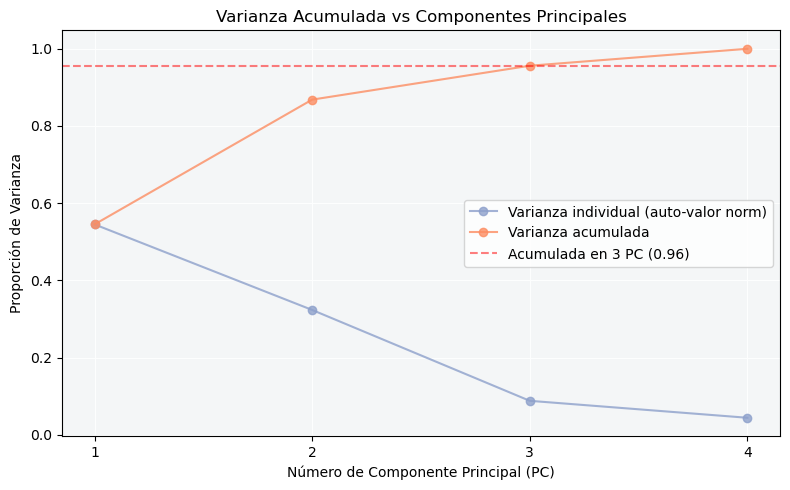

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("data_banknote_authentication.csv", sep=";")

# Separar variables
X = df.drop(columns=['class'])
Y = df['class']

# Estandarizar los datos 
X_zscaled = (X - X.mean()) / X.std(ddof=1)

# Calcular matriz de covarianza y extraer auto-vectores
eigenvalues, eigenvectors = np.linalg.eig(np.cov(X_zscaled, rowvar=False))

# ORDENAR 
idx = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, idx]
eigenvalues = eigenvalues[idx]

# Calcular varianza
eigenvalues_normalized = eigenvalues / eigenvalues.sum()
cumvar_explained = np.cumsum(eigenvalues_normalized)

# Extraemos solo las primeras 3 columnas de los auto-vectores ordenados
eigenvectors_3 = eigenvectors[:, 0:3]


T_3 = pd.DataFrame(X_zscaled.dot(eigenvectors_3))
T_3.columns = ['pc1', 'pc2', 'pc3']


T_3 = pd.concat([T_3, Y], axis=1)

print("--- Dataset proyectado a 3 Componentes Principales ---")
print(T_3.head())
print(f"\\nVarianza total retenida con 3 componentes: {cumvar_explained[2]*100:.2f}%")


eje_x_componentes = range(1, len(cumvar_explained) + 1)

plt.figure(figsize=(8, 5))


plt.plot(eje_x_componentes, 
         eigenvalues_normalized, 
         '-o', 
         color='#8da0cb', 
         label='Varianza individual (auto-valor norm)', 
         alpha=0.8)


plt.plot(eje_x_componentes, 
         cumvar_explained, 
         '-o', 
         color='#fc8d62', 
         label='Varianza acumulada', 
         alpha=0.8)


plt.axhline(y=cumvar_explained[2], color='red', linestyle='--', alpha=0.5, label=f'Acumulada en 3 PC ({cumvar_explained[2]:.2f})')

plt.title('Varianza Acumulada vs Componentes Principales')
plt.xlabel('Número de Componente Principal (PC)')
plt.ylabel('Proporción de Varianza')
plt.xticks(eje_x_componentes)
plt.legend(loc='center right')
plt.grid(color='#fdfefe')
plt.gca().set_facecolor('#f4f6f7')
plt.tight_layout()
plt.show()

___

## Parte 3

Como en el segundo gráfico del cuaderno visto en clase sobre PCA, grafique los tres mayores componentes principales utilizando la bibioteca **plotly** https://plotly.com/python/3d-scatter-plots/  **(10 puntos)**


___

In [6]:
import plotly.express as px


T_3['class'] = T_3['class'].astype(str)


fig = px.scatter_3d(
    T_3, 
    x='pc1', 
    y='pc2', 
    z='pc3', 
    color='class',
    title='Proyección PCA 3D',
    labels={'pc1': 'PC 1', 'pc2': 'PC 2', 'pc3': 'PC 3'},
    opacity=0.7,  
    color_discrete_sequence=px.colors.qualitative.Set1
)


fig.update_traces(marker=dict(size=4))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))

# Desplegamos la figura
fig.show()